# Two bit Qmultiplier

In [2]:
def TwoBitQuantumMultiplier(number1 = None, number2 = None):

    from qiskit import QuantumCircuit
    from CircuitMakingFunctions import  makeHalfAdder
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate

        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(4,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"A1")
    qr2 = QuantumRegister(1,"A2")
    qr3 = QuantumRegister(1,"B1")
    qr4 = QuantumRegister(1,"B2")
    qr5 = QuantumRegister(1,"Carry1")
    qr6 = QuantumRegister(1,"Prod1")
    qr7 = QuantumRegister(1,"Prod2")
    qr8 = QuantumRegister(1,"Prod3")
    qr9 = QuantumRegister(1,"Prod4")
    qr10 = QuantumRegister(1,"Temp1")
    qr11 = QuantumRegister(1,"Temp2")
    # qr23 = QuantumRegister(1,"Two's carry")

    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, cr, name='Full-adder circuit')

    control_1 = 0
    A1 = 1
    A2 = 2
    B1 = 3
    B2 = 4
    Carry1 = 5
    Prod1 = 6
    Prod2 = 7
    Prod3 = 8
    Prod4 = 9
    Temp1 = 10
    Temp2 = 11

    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 3 or number2 < 0 or number2 > 3)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        count = 1
        if(len(binary1) != 2):
            length = 2 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 2):
            length = 2 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        print(f"first operand {binary1} and second operand {binary2}\n")
    
    #read the input and set the 
    #appropiate qbits to |1>
        for x in range(2):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 3
        for x in range(2):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 1
        for x in range(2):
            qc.append(HGate(), [count])
            count += 1

        count = 3
        for x in range(2):
            qc.append(HGate(), [count])
            count += 1

    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    #half adder args:     control_1 = 0
    # A = 1
    # B = 2
    # Sum = 3
    # Carry = 4

    #First, and between A2 and B2 for Prod1

    half_adder = makeHalfAdder()
    #Calc the 4th bit by doing A2 AND B2
    qc.append(CCXGate(), [A2, B2, Prod4])

    #Prod3 is the result sum of the half adder whos inputs are: A1 AND B2, and A2 AND B2
        #B2 AND A1 makes the A for the first half adder
    qc.append(CCXGate(), [A1, B2, Temp1])
        #B1 AND A2 makes the B for the first half adder
    qc.append(CCXGate(), [A2, B1, Temp2])

    # Half adder(control = control 1, A = Temp1, B = Temp 2, S = Prod 3, carry = Carry1)
    qc.append(half_adder, [control_1, Temp1, Temp2, Prod3, Carry1])

    #Clean the temp registers
            #undo B1 AND A2 
    qc.append(CCXGate(), [A2, B1, Temp2])

            #undo B2 AND A1 
    qc.append(CCXGate(), [A1, B2, Temp1])

    #Now, do A1 and B1 for the last half-adder's B (A is carry 1)
    qc.append(CCXGate(), [A1, B1, Temp1])

    qc.append(half_adder, [control_1, Temp1, Carry1, Prod2, Prod1 ])

    #clean temp 1
    qc.append(CCXGate(), [A1, B1, Temp1])

    # #now we can meassure the prods

    qc.measure(Prod4, 0)
    qc.measure(Prod3, 1)
    qc.measure(Prod2, 2)
    qc.measure(Prod1, 3)
    

   #COMMENT THIS MARKED SECTION WHEN USING THE TESTS AND METRICS FUNCTION --------------------------------------
    # display(qc.draw("mpl"))
    # samplerSim = StatevectorSampler()
    # result = samplerSim.run([qc], shots=(1024*4)).result()
    # counts = result[0].data.classicalRegister.get_counts()
    # pretty_counts = {}
    # # res = 0
    # for bitstring, count in counts.items():
    #     prod_bits = bitstring

    #     label = f"product bits={prod_bits}, Product={int(bitstring,2)}"
    #     pretty_counts[label] = count
    #     if(number1 != None and number2 != None):
    #             print(bitstring, "→",
    #                 "prod bits =", bitstring,
    #                 "Result =", int(bitstring, 2),"\n")
    #             # res = int(bitstring, 2)
    #     res = bitstring
    # if(carry == "0"):
    #     print("we need two's comp.")

    # display(plot_histogram(pretty_counts, title="multiplier"))
   #-----------------------------------------------------------------------------------------------





    return qc

In [ ]:
from Quantum_Circuit_Tests_and_metrics import runQCTests_and_metrics
TwoBitQMult = TwoBitQuantumMultiplier(0,0)
runQCTests_and_metrics(TwoBitQMult,mode = "mult",title="Two bit binary Q-multiplier")


# Distribution

Quantum circuit being evaluated:  


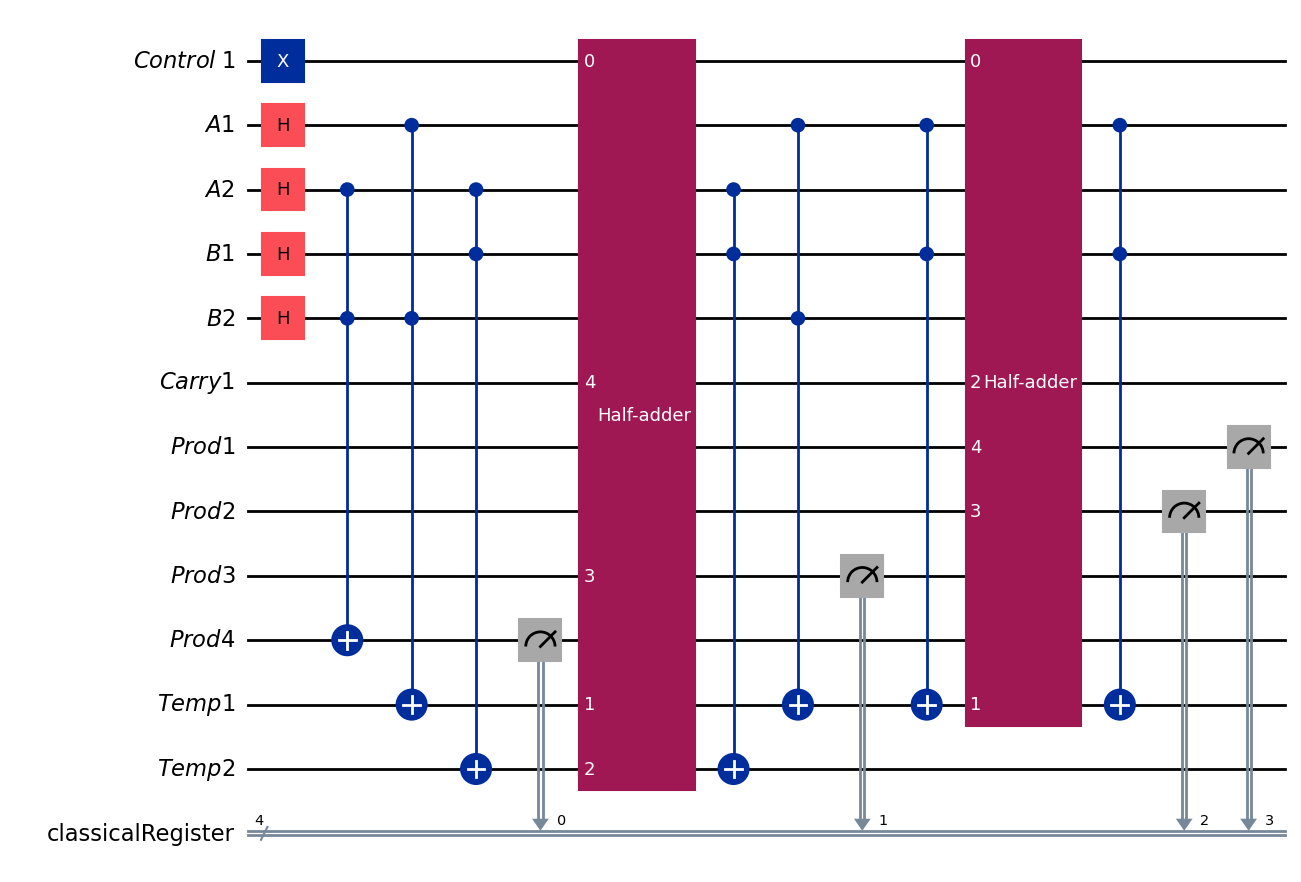

Transpiled qc and got the backend
job_id: d9ag4q66hjac73febtsg
Job metrics: {'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.45.0,qiskit-2.3.0*,qiskit_aer-0.17.2', 'timestamps': {'created': '2026-07-13T15:21:12.096222Z', 'finished': '2026-07-13T15:28:47.818616Z', 'running': '2026-07-13T15:28:36.516606Z'}, 'bss': {'seconds': 3}, 'usage': {'quantum_seconds': 0, 'seconds': 0, 'status': 'pending'}}

Job duration {'quantum_seconds': 3, 'seconds': 3, 'status': 'complete'}


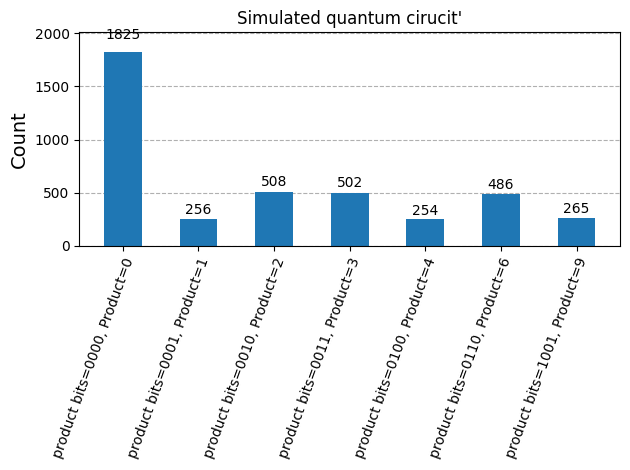

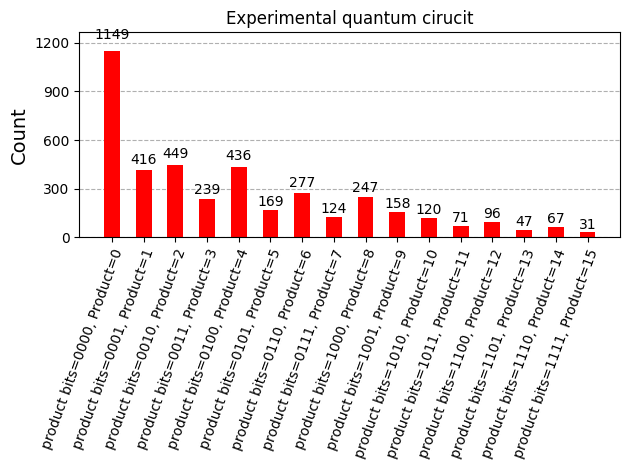

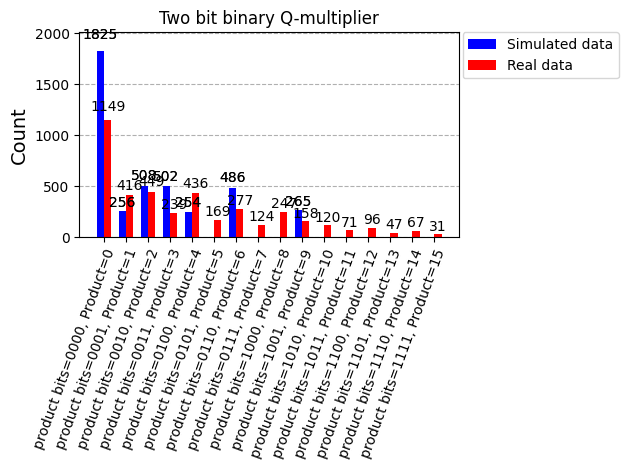




Simualted Quantum Cirucit depth vs transpiled quantum circuit's depth
og quantum cirucit's depth: 8
transpiled 4-bit quantum cirucit''s depth: 787

Meassuring quantum circuit's T-depth
T-depth: 56
Hardware metrics

Name of metric: T1
Name of unit used for metric: us
Value of metric: 281.60263020903125

---------------------------------------- 

Name of metric: T2
Name of unit used for metric: us
Value of metric: 300.09207345377166

---------------------------------------- 

Name of metric: readout_error
Value of metric: 0.007080078125

---------------------------------------- 

Name of metric: prob_meas0_prep1
Value of metric: 0.0107421875

---------------------------------------- 

Name of metric: prob_meas1_prep0
Value of metric: 0.00341796875

---------------------------------------- 

Name of metric: readout_length
Name of unit used for metric: ns
Value of metric: 2180

---------------------------------------- 



In [4]:
from Quantum_Circuit_Tests_and_metrics import runQCTests_and_metrics

TwoBitQMult2 = TwoBitQuantumMultiplier()
runQCTests_and_metrics(TwoBitQMult2,mode = "mult",title="Two bit binary Q-multiplier")

# Three bit Qmultiplier (Ignore for now)

In [ ]:
# def ThreeBitQuantumMultiplier(number1 = None, number2 = None):

#     from qiskit import QuantumCircuit
#     from CircuitMakingFunctions import makeFullAdder, makeHalfAdder
#     from qiskit.circuit import QuantumRegister, ClassicalRegister
#     from qiskit.visualization import plot_histogram
#     from qiskit.circuit.library import CCXGate, XGate, HGate


#         #since these operations are from right to left, we iterate backwards:
        
#     cr = ClassicalRegister(6,"classicalRegister")
#     qr0 = QuantumRegister(1,"Control 1")
#     qr1 = QuantumRegister(1,"A2")
#     qr2 = QuantumRegister(1,"A1")
#     qr3 = QuantumRegister(1,"A0")
#     qr4 = QuantumRegister(1,"B2")
#     qr5 = QuantumRegister(1,"B1")
#     qr6 = QuantumRegister(1,"B0")
#     qr7 = QuantumRegister(1,"Carry1")
#     qr8 = QuantumRegister(1,"Prod1")
#     qr9 = QuantumRegister(1,"Prod2")
#     qr10 = QuantumRegister(1,"Prod3")
#     qr11 = QuantumRegister(1,"Prod4")
#     qr12 = QuantumRegister(1,"Prod5")
#     qr13 = QuantumRegister(1,"Prod6")
#     qr14 = QuantumRegister(1,"Temp1")
#     qr15= QuantumRegister(1,"Temp2")
#     qr16= QuantumRegister(1,"Temp3")

#     qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, qr14, qr15, qr16, cr, name='Full-adder circuit')

#     control_1 = 0
#     A2 = 1
#     A1 = 2
#     A0 = 3
#     B2 = 4
#     B1 = 5
#     B0 = 6
#     Carry1 = 7
#     Carry2 = 8
#     Carry3 = 9
#     Carry4 = 10
#     Carry5 = 11
#     Carry6 = 12
#     Prod1 = 13
#     Prod2 = 14
#     Prod3 = 15
#     Prod4 = 16
#     Prod5 = 17
#     Prod6 = 18
#     Temp1 = 19
#     Temp2 = 20
#     Temp3 = 21
#     Sum1 = 22
#     Sum2 = 23
#     Sum3 = 24
#     Sum4 = 25
#     Sum5 = 26
#     Sum6 = 27

#     if(number1 != None and number2 != None):
#         if((number1 < 0 or number1 > 7 or number2 < 0 or number2 > 7)):
#             print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
#             return False
#         binary1 = bin(number1)[2:]
#         binary2 = bin(number2)[2:]
#         count = 1
#         if(len(binary1) != 3):
#             length = 3 - len(binary1)
#             buff = ""
#             for x in range(0, (length)):
#                 buff += "0"
#             binary1 = buff + binary1
#         if(len(binary2) != 3):
#             length = 3 - len(binary2)
#             buff = ""
#             for x in range(0, (length)):
#                 buff += "0"
#             binary2 = buff + binary2
#         print(f"first operand {binary1} and second operand {binary2}\n")
    
#     #read the input and set the 
#     #appropiate qbits to |1>
#         for x in range(3):
#             if(binary1[x] == "1"):
#                 qc.append(XGate(), [count])
#             count += 1

#         count = 4
#         for x in range(3):
#             if(binary2[x] == "1"):
#                 qc.append(XGate(), [count])
#             count += 1
#     else:
#         count = 1
#         for x in range(3):
#             qc.append(HGate(), [count])
#             count += 1

#         count = 4
#         for x in range(3):
#             qc.append(HGate(), [count])
#             count += 1

#     #set the control bit to |1>
#     qc.append(XGate(), [control_1])
#     #half adder args:     
#     # control_1 = 0
#     # A = 1
#     # B = 2
#     # Sum = 3
#     # Carry = 4



#     #First, and between A1 and B2 for Prod1

#     half_adder = makeHalfAdder()
#     #Calc the 6th bit by doing A0 AND B0
#     qc.append(CCXGate(), [A0, B0, Prod6])

#     #Prod5 is the result sum of the half adder whos inputs are: A1 AND B0, and A0 AND B2
#         #B0 AND A1 makes the A for the first half adder
#     qc.append(CCXGate(), [A1, B0, Temp1])
#         #B1 AND A0 makes the B for the first half adder
#     qc.append(CCXGate(), [A0, B1, Temp2])

#     # Half adder(control = control 1, A = Temp1, B = Temp 2, S = Prod 3, carry = Carry1)
#     qc.append(half_adder, [control_1, Temp1, Temp2, Prod5, Carry1])

#     #Clean the temp registers
#             #undo B1 AND A0 
#     qc.append(CCXGate(), [A0, B1, Temp2])

#             #undo B0 AND A1 
#     qc.append(CCXGate(), [A1, B0, Temp1])


#     #Prepare for the first full adder:
#     #Prepare B0 AND A2
#     qc.append(CCXGate(), [A2, B0, Temp1])
#     qc.append(CCXGate(), [A1, B1, Temp2])

#     fullAdder1 = makeFullAdder()

#     #Full adders args:
#     #control_1 = 0
#     # control_2 = 1
#     # A = 2
#     # B = 3
#     # Carry_in = 4
#     # Carry_out = 5
#     # Sum = 6
#     # Temp1 = 7
#     # Temp2 = 8
#     # Temp3 = 9
#     # sub = 10

#     qc.append(fullAdder1, [control_1, Temp1, Temp2, Carry1, Carry2, ])
    





#     # #now we can meassure the prods

#     qc.measure(Prod6, 0)
#     qc.measure(Prod5, 1)
#     qc.measure(Prod4, 2)
#     qc.measure(Prod3, 3)
#     qc.measure(Prod2, 4)
#     qc.measure(Prod1, 5)
    

#    #COMMENT THIS MARKED SECTION WHEN USING THE TESTS AND METRICS FUNCTION --------------------------------------
#     # display(qc.draw("mpl"))
#     # samplerSim = StatevectorSampler()
#     # result = samplerSim.run([qc], shots=(1024*4)).result()
#     # counts = result[0].data.classicalRegister.get_counts()
#     # pretty_counts = {}
#     # # res = 0
#     # for bitstring, count in counts.items():
#     #     prod_bits = bitstring

#     #     label = f"product bits={prod_bits}, Product={int(bitstring,2)}"
#     #     pretty_counts[label] = count
#     #     if(number1 != None and number2 != None):
#     #             print(bitstring, "→",
#     #                 "prod bits =", bitstring,
#     #                 "Result =", int(bitstring, 2),"\n")
#     #             # res = int(bitstring, 2)
#     #     res = bitstring
#     # if(carry == "0"):
#     #     print("we need two's comp.")

#     # display(plot_histogram(pretty_counts, title="multiplier"))
#    #-----------------------------------------------------------------------------------------------





#     return qc